# Regressão em Músicas de Stray Kids
> Stray Kids é uma banda de K-POP, bastante famosa aqui no Brasil, Coreia e Japão

A análise e o trabalho feito nesse notebook será baseado em um modelo de regressão para tentativa de prever o número de reproduções de uma música baseada em características da música e do album.

Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Lendo o CSV 

> Atenção, como a banda é coreana e famosa na ÁSIA, precisamos adaptar alguns caracteres para que o python possa lê-los corretamente

In [2]:
def load_csv(path):

    encodings = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin1",
        "cp949",
        "euc-kr"
    ]

    for enc in encodings:
        try:
            return pd.read_csv(
                path,
                encoding=enc
            )
        except UnicodeDecodeError:
            pass

    raise ValueError(
        f"Encoding não identificado: {path}"
    )

df = load_csv(
    "spotify_skz_counts_album.csv"
)

print(df.shape)

display(df.head())

(309, 12)


,release_year,album_type,album_name,track_name,bpm,number_of_streams,total_time_played,total_time_played_h,average_ms_played,average_ms_played_min,song_length_min,avg_percent_song_played
0,2018,Mini Album,I am NOT,3rd Eye,140,32,7554514,2:05:55,236078.56,3:56,4:03,97
1,2018,Mini Album,I am NOT,Awaken,164,33,6399256,1:46:39,193916.85,3:13,3:13,100
2,2018,Mini Album,I am NOT,District 9,90,151,32233152,8:57:13,213464.58,3:33,3:33,100
3,2018,Mini Album,I am NOT,Grow Up,174,23,4881245,1:21:21,212228.04,3:32,3:33,100
4,2018,Mini Album,I am NOT,Mirror,186,26,5329113,1:28:49,204965.88,3:25,3:42,92


In [3]:
print(df.columns.tolist())

['release_year', 'album_type', 'album_name', 'track_name', 'bpm', 'number_of_streams', 'total_time_played', 'total_time_played_h', 'average_ms_played', 'average_ms_played_min', 'song_length_min', 'avg_percent_song_played']


Aqui vem nosso objetivo, o número de streams das músicas

In [4]:
target = "number_of_streams"

X = df.drop(columns=[target])

y = df[target]

Aqui já vamos ensinar o modelo a prever o número de reproduções

In [5]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numéricas:")
print(numeric_features)

print()

print("Categóricas:")
print(categorical_features)

Numéricas:
['release_year', 'bpm', 'total_time_played', 'average_ms_played', 'avg_percent_song_played']

Categóricas:
['album_type', 'album_name', 'track_name', 'total_time_played_h', 'average_ms_played_min', 'song_length_min']


In [6]:
numeric_transformer = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_transformer = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    [
        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline(
    [
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )
    ]
)

pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['release_year','album_type','album_name',...,'average_ms_played_min', 'song_length_min','avg_percent_song_played']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [9]:
preds = pipeline.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")

MAE  = 3.67
RMSE = 7.54
R²   = 0.9937


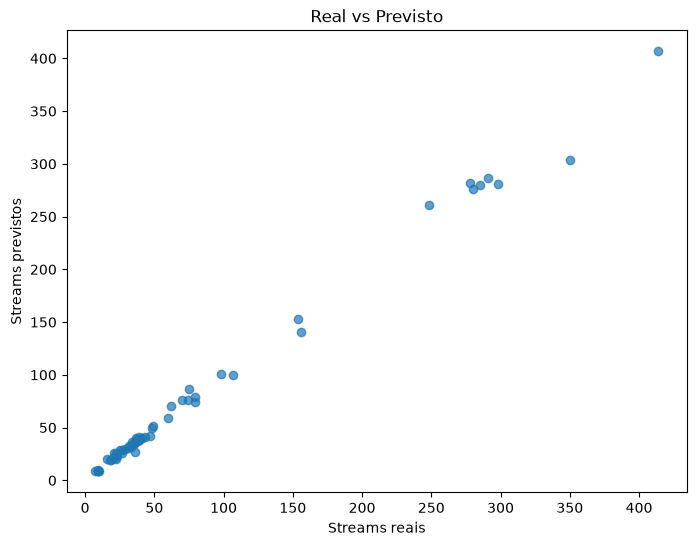

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    preds,
    alpha=0.7
)

plt.xlabel("Streams reais")

plt.ylabel("Streams previstos")

plt.title(
    "Real vs Previsto"
)

plt.show()

In [11]:
results = pd.DataFrame(
    {
        "real": y_test,
        "previsto": preds
    }
)

display(results.head())

results.to_csv(
    "spotify_predictions.csv",
    index=False
)

,real,previsto
288,48,49.153333
9,21,22.490000
57,36,27.326667
60,19,19.246667
25,7,8.380000
